In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from tqdm import tqdm

curr_path = '.'

sigma_0=0.4 # variance of ground truths
d=10 # dimension of feature vectors
r=6 # rank of feature vectors
s=6 # samples of feature vectors per task
M=[1,5,10,20] # number of experts
flg=len(M)
N=7 # number of ground truths, with K=3
K=3
_eta=0.5 # learning rate
_lambda=0.3 # upper bound of the random noise
_alpha=0.5 # scalar of the auxiliary loss function
T=2000 # number of task arrivals



def update_w(w_last, X_t,y_t):
    X=X_t
    y=y_t
    w_init=w_last
    wt =  (y - w_init @ X) @ np.linalg.pinv(X) + w_init
    return wt

def generate_feature_matrix(w_0,v_0,w_index):
    X_t=np.zeros((d,s))
    y_t=np.zeros(s)
    for i in range(0,s):
        temp_X = np.random.randn(r)
        temp_X = 0.1*temp_X/np.linalg.norm(temp_X)
        X_t[:r,i]=temp_X
    v_position=np.random.randint(0,s)
    # w_index=np.random.randint(0,N)
    for i in range(0,d):
        X_t[i,v_position]=v_0[w_index,i]
    for j in range(r,d):
        if j-r != v_position:
            X_t[j,:]=X_t[j-r,:]*np.random.randn(1)*0.001
        else:
            X_t[j,:]=X_t[j-r,:]*np.random.randn(1)*0.00001
    y_t=w_0[w_index] @ X_t
    return X_t, y_t

def update_theta(task_grad,theta_init,flag):
    theta_t=np.zeros((M[flag],d))
    for i in range(0,M[flag]):
        for j in range(0,d):
            theta_t[i][j]=theta_init[i][j]-_eta*task_grad[i][j]
    return theta_t


def soft_max(h_value,flag):
    sum_exp=0
    softmax_m=np.zeros(M[flag])
    for i in range(0,M[flag]):
        sum_exp += np.exp(h_value[i])
    for i in range(0,M[flag]):
        softmax_m[i] = np.exp(h_value[i])/sum_exp
    return softmax_m

def cal_gradient(pi_t,w_init,wt_m,X_t,t,f_t,mt,flag):
    loc_grad=np.zeros((M[flag],d))
    aux_grad=np.zeros((M[flag],d))
    task_grad=np.zeros((M[flag],d))
    model_error=[x - y for x, y in zip(wt_m, w_init)]
    error_norm=np.linalg.norm(model_error) # calculate ||w_t-w_{t-1}||_2
    sum_X=np.zeros(d)
    for i in range(0,s): # calculate \sum_{i=0}^{s} X_{t,i}
        temp_sum=[x + y for x, y in zip(sum_X, np.transpose(X_t)[i])]
        sum_X=temp_sum

    for i in range(0,M[flag]):
        if i==mt:
            for j in range(0,d):
                loc_grad[i][j]=pi_t[mt]*(1-pi_t[mt])*error_norm*sum_X[j]
                aux_grad[i][j]=pi_t[mt]*(1-pi_t[mt])*_alpha*M[flag]/(t+1)*sum_X[j]
        else:
            for j in range(0,d):
                loc_grad[i][j]=-pi_t[mt]*pi_t[i]*sum_X[j]*error_norm
                aux_grad[i][j]=-pi_t[mt]*pi_t[i]*sum_X[j]*_alpha*M[flag]/(t+1)
        task_grad[i]=[x + y for x, y in zip(loc_grad[i], aux_grad[i])]

    return task_grad

def max_len(expert_set,flag):
    max_length=-1
    res=0
    for i in range(M[flag]):
        if len(expert_set[i]) > max_length:
            max_length = len(expert_set[i])
            res = i
    return res

def cal_F_and_G(t, mt_record, wt_record,w_record):
    Ft=0
    Gt=0
    model_error_t = np.zeros(d)
    model_error_i = np.zeros(d)
    for i in range(0,t-1):
        model_error_t=[x - y for x, y in zip(wt_record[t+1][mt_record[i]], w_record[i])]
        error_t= np.linalg.norm(model_error_t)
        model_error_i=[x - y for x, y in zip(wt_record[i+1][mt_record[i]], w_record[i])]
        error_i= np.linalg.norm(model_error_i)
        Ft +=  abs(error_t - error_i)
    Ft /= t
    for i in range(0,t):
        model_error=[x - y for x, y in zip(wt_record[t+1][mt_record[i]], w_record[i])]
        error_G= np.linalg.norm(model_error)
        Gt += abs(error_G)
    Gt /= (t+1)
    return Ft, Gt



w_0 = np.zeros((N, d))
v_0 = np.zeros((N, d))
w_pool, v_pool=generate_ground_truth(w_0,v_0)


index_record=[]
for i in range(T):
    index_record.append(np.random.randint(0,N))
Ft_record=np.zeros((flg,T))
Gt_record=np.zeros((flg,T))

cnt=1
Ft_record_average=np.zeros((flg,T))
Gt_record_average=np.zeros((flg,T))
for count in tqdm(range(cnt)):
    for flag in range(flg):
        Im=np.zeros((flg,M[flag]))
        mt_record=np.arange(T)
        for i in range(T):
            mt_record[i]=1
        wt_record=np.zeros((T+1,M[flag],d))
        theta=np.zeros((T,M[flag],d))
        w_record=np.zeros((T,d))


        expert_record=[]
        for i in range(0,M[flag]):
            expert_record.append([])

        ft=0
        theta_gradient=np.zeros((T,M[flag],d))
        softmax_value=np.zeros((T,M[flag]))

        for t in range(0,T):
            ht=np.zeros(M[flag])
            w_index=index_record[t]
            Xt, yt = generate_feature_matrix(w_pool, v_pool, w_index)
            w_record[t]=w_pool[w_index]
            ht_maxtrix=theta[t] @ Xt
            for i in range(0,M[flag]):
                for j in range(0,s):
                    ht[i] += ht_maxtrix[i,j]
            rt = np.random.uniform(0,_lambda,M[flag])
            ht_noise=[x + y for x, y in zip(ht, rt)]
            softmax_value[t]=soft_max(ht_noise,flag)
            for i in range(0,M[flag]):
                if softmax_value[t][i] == np.max(softmax_value[t]):
                    mt_record[t]=i
                    wt_record[t+1][i]=update_w(wt_record[t][i], Xt,yt)
                    expert_record[i].append(w_index)
                else:
                    wt_record[t+1][i]=wt_record[t][i]
            if t >= M[flag]/_eta:
                for i in range(0,M[flag]):
                    if i != mt_record[t]:
                        if abs(ht_noise[i]-ht_noise[mt_record[t]])<sigma_0**(1.25):
                            Im[flag][i]=1
            if sum(Im[flag])!=M[flag] or t<80+M[flag]*3:
                theta_gradient[t] = cal_gradient(softmax_value[t],wt_record[t][mt_record[t]],wt_record[t+1][mt_record[t]],Xt,t,ft,mt_record[t],flag)
                theta_temp = update_theta(theta_gradient[t],theta[t],flag)
                if t <T-1:
                    theta[t+1]=theta_temp
            else:
                ft+=1
                if t <T-1:
                    theta[t+1]=theta[t]
            # Calculate forgetting and generalization error
            if t >=1:
                Ft_record[flag][t], Gt_record[flag][t]=cal_F_and_G(t, mt_record, wt_record,w_record)
            else:
                Ft_record[flag][t] = 0
                model_error=[x - y for x, y in zip(wt_record[t+1][:,mt_record[i]], w_record[i])]
                error_G = np.linalg.norm(model_error)
                Gt_record[flag][t] = error_G
        Ft_record_average[flag] += Ft_record[flag]
        Gt_record_average[flag] += Gt_record[flag]
Ft_record_average/=cnt
Gt_record_average/=cnt

#---------------------------------------------------------------------------------------

plt.rcParams.update({'figure.autolayout': True})
plt.rcParams.update({'font.size': 16})
all_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
_style = ['-', '--', '-.', ':', '-']
x_axis=np.arange(T)

f = plt.figure(1)


for i in range(flg):
    plt.plot(x_axis, Ft_record_average[i], _style[i], color=all_colors[i], label='$M={}$'.format(M[i]))
plt.xlabel("Rounds")
plt.ylabel("forgetting $F_t$")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(os.path.join(curr_path, 'forgetting_algo1.pdf'),
            format='pdf', bbox_inches='tight')

g = plt.figure(2)
for i in range(flg):
    plt.plot(x_axis, Gt_record_average[i], _style[i], color=all_colors[i], label='$M={}$'.format(M[i]))
plt.xlabel("Rounds")
plt.ylabel("error $G_t$")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.savefig(os.path.join(curr_path, 'error_algo1.pdf'),
            format='pdf', bbox_inches='tight')

plt.show()




def update_w_with_kl(w_last, X_t, y_t, w_prior, beta=0.1):
    """
    """
    X = X_t
    y = y_t
    w_unreg = (y - w_last @ X) @ np.linalg.pinv(X) + w_last

    w_reg = (1 - beta) * w_unreg + beta * w_prior

    return w_reg

def calculate_drift(wt_record, mt_record, w_record, t):
    """

    """
    drift = 0
    counts = np.zeros(len(wt_record[0]))

    for i in range(t):
        expert_idx = mt_record[i]
        counts[expert_idx] += 1
        if counts[expert_idx] > 1:
            initial_params = wt_record[int(counts[expert_idx])][expert_idx]
            current_params = wt_record[i+1][expert_idx]
            drift += np.linalg.norm(current_params - initial_params)

    active_experts = np.sum(counts > 0)
    return drift / max(active_experts, 1)

drift_record = np.zeros((flg, T))
drift_record_kl = np.zeros((flg, T))

drift_record[flag][t] = calculate_drift(wt_record, mt_record, w_record, t)

wt_record_kl = wt_record.copy()
w_prior = wt_record[t][mt_record[t]]
wt_record_kl[t+1][mt_record[t]] = update_w_with_kl(
    wt_record[t][mt_record[t]],
    Xt, yt,
    w_prior,
    beta=0.3
)
drift_record_kl[flag][t] = calculate_drift(wt_record_kl, mt_record, w_record, t)


h = plt.figure(3)
for i in range(flg):
    plt.plot(x_axis, drift_record[i], _style[i], color=all_colors[i],
             label=f'Base MoE M={M[i]}')
    plt.plot(x_axis, drift_record_kl[i], _style[i], color=all_colors[i],
             linestyle='--', label=f'KL-MoE M={M[i]}')
plt.xlabel("Rounds")
plt.ylabel("Parameter Drift")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(os.path.join(curr_path, 'parameter_drift.pdf'),
            format='pdf', bbox_inches='tight')
h = plt.figure(3)
for i in range(flg):
    plt.plot(x_axis, drift_record[i], _style[i], color=all_colors[i],
             label=f'Base MoE M={M[i]}')
    plt.plot(x_axis, drift_record_kl[i], _style[i], color=all_colors[i],
             linestyle='--', label=f'KL-MoE M={M[i]}')
plt.xlabel("Rounds")
plt.ylabel("Parameter Drift")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(os.path.join(curr_path, 'parameter_drift.pdf'),
            format='pdf', bbox_inches='tight')




  0%|          | 0/1 [00:23<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
def analyze_task_forgetting(
    T, N, K, M, flg,
    wt_record, wt_record_kl,
    mt_record, Ft_record, Gt_record,
    drift_record, drift_record_kl
):
    """
    Comprehensive analysis of task forgetting metrics across different methods

    Args:
        T: Number of rounds
        N: Number of total ground truths
        K: Number of distinct task types
        M: List of expert counts for different configurations
        flg: Length of M (number of configurations)
        wt_record:   Expert parameter history (base MoE)
        wt_record_kl:Expert parameter history (KL regularization)
        mt_record:   Expert assignment history
        Ft_record:   Forgetting measure history (base MoE)
        Gt_record:   Error measure history
        drift_record:      Parameter drift history (base MoE)
        drift_record_kl:   Parameter drift history with KL
    """
    # Initialize metrics storage
    metrics = {
        'Base MoE':          np.zeros((flg, K)),
        'KL-MoE':            np.zeros((flg, K)),
        'Task Error':        np.zeros((flg, K)),
        'Routing Stability': np.zeros((flg, K)),
    }

    for flag in range(flg):
        for task in range(K):
            task_indices = [t for t in range(T) if mt_record[t] == task]

            if task_indices:
                metrics['Base MoE'][flag, task] = np.mean(Ft_record[flag, task_indices])

                metrics['KL-MoE'][flag, task] = np.mean(drift_record_kl[flag, task_indices])

                metrics['Task Error'][flag, task] = np.mean(Gt_record[flag, task_indices])

                expert_assignments = np.array([mt_record[t] for t in task_indices])
                if len(expert_assignments) > 0:
                    primary_expert = np.bincount(expert_assignments).argmax()
                    routing_stability = np.mean(expert_assignments == primary_expert)
                else:
                    routing_stability = 0.0

                metrics['Routing Stability'][flag, task] = routing_stability

    print("\nComprehensive Task Forgetting Analysis")
    print("=" * 80)

    for metric_name, metric_values in metrics.items():
        print(f"\n{metric_name} Results:")
        print("-" * 80)
        print(f"{'M':<10}", end="")
        for task in range(K):
            print(f"Task {task+1:>8}", end="")
        print()
        print("-" * 80)

        for flag in range(flg):
            print(f"{M[flag]:<10}", end="")
            for task in range(K):
                print(f"{metric_values[flag, task]:8.3f}", end="")
            print()
    print("\nFinal Round Values (Round 1000):")
    print("--------------------------------")
    for flag in range(flg):
        final_forgetting = Ft_record[flag, -1]
        print(f"M={M[flag]:<2}: {final_forgetting:.4f}")
    print("\nSummary Statistics")
    print("=" * 80)
    for metric_name, metric_values in metrics.items():
        mean_per_config = np.mean(metric_values, axis=1)
        std_per_config  = np.std(metric_values, axis=1)

        print(f"\n{metric_name} Summary:")
        print("-" * 80)
        print(f"{'M':<10}{'Mean':>12}{'Std':>12}")
        print("-" * 80)

        for flag in range(flg):
            print(f"{M[flag]:<10}{mean_per_config[flag]:12.3f}{std_per_config[flag]:12.3f}")

    return metrics

In [ ]:
def update_w_with_kl(w_last, X_t, y_t, w_prior, beta=0.3):
    """Update expert parameters with KL regularization"""
    w_unreg = (y_t - w_last @ X_t) @ np.linalg.pinv(X_t) + w_last
    if w_prior is None or beta == 0:
        return w_unreg
    w_reg = (1 - beta) * w_unreg + beta * w_prior
    return w_reg

def unified_moe_update(Xt, yt, theta_t, wt_record_t, priors, beta, flag, frozen_gates=None):
    """
    Implements the unified MoE update with a joint Bayesian objective
    for both gating and experts.

    Args:
        Xt (ndarray): Input features at time t.
        yt (ndarray): Target at time t.
        theta_t (ndarray): Current gating parameters (shape: [M_experts, d]).
        wt_record_t (ndarray): Current expert parameters (shape: [M_experts, d]).
        priors (dict): Dictionary containing prior distributions for experts and gating:
                       priors['experts'][m], priors['gating'][m].
        beta (float): KL regularization weight.
        flag (int): Configuration index (for referencing M[flag]).
        frozen_gates (set): Indices of experts for which gating parameters are frozen.

    Returns:
        theta_new (ndarray): Updated gating parameters (shape: [M_experts, d]).
        wt_record_new (ndarray): Updated expert parameters (shape: [M_experts, d]).
        selected_expert (int): Index of the currently chosen expert.
        is_confident (bool): Whether the gating was “confident” (beyond threshold).
        probs_new (ndarray): Updated gating probabilities after the parameter updates.
    """

    M_experts = len(wt_record_t)
    frozen_gates = frozen_gates or set()

    h_matrix = theta_t @ Xt
    h = np.sum(h_matrix, axis=1)
    probs = soft_max(h, flag)


    theta_grad = np.zeros_like(theta_t)
    w_updates  = np.zeros_like(wt_record_t)

    for m in range(M_experts):
        if m in frozen_gates:
            continue

        expert_output = wt_record_t[m] @ Xt
        pred_error    = yt - expert_output

        if priors['experts'][m] is not None:
            expert_kl = calculate_expert_kl(wt_record_t[m], priors['experts'][m])
        else:
            expert_kl = 0

        if (priors['gating'] is not None) and (m not in frozen_gates):
            gate_kl = calculate_gate_kl(theta_t[m], priors['gating'][m])
        else:
            gate_kl = 0

        w_updates[m] = (
            (pred_error @ np.linalg.pinv(Xt)) * probs[m]
            - beta * expert_kl
        )

        if m not in frozen_gates:
            theta_grad[m] = (
                probs[m] * (1 - probs[m])
                * (np.linalg.norm(pred_error) * np.sum(Xt, axis=1)
                   - beta * gate_kl)
            )


    theta_new      = theta_t.copy()
    wt_record_new  = wt_record_t.copy()

    for m in range(M_experts):
        if m not in frozen_gates:
            theta_new[m] = theta_t[m] - _eta * theta_grad[m]
        wt_record_new[m] = wt_record_t[m] + _eta * w_updates[m]


    h_new     = theta_new @ Xt
    probs_new = soft_max(np.sum(h_new, axis=1), flag)
    selected_expert = np.argmax(probs_new)

    epsilon = 0.1
    is_confident = probs_new[selected_expert] > (1 - epsilon)

    if is_confident:
        priors['experts'][selected_expert] = wt_record_new[selected_expert].copy()
        if selected_expert not in frozen_gates:
            priors['gating'][selected_expert] = theta_new[selected_expert].copy()

    return theta_new, wt_record_new, selected_expert, is_confident, probs_new

In [ ]:
def calculate_expert_kl(w_current, w_prior):
    if w_prior is None:
        return 0
    return np.sum((w_current - w_prior) ** 2)
def calculate_gate_kl(theta_current, theta_prior):
    if theta_prior is None:
        return 0
    return np.sum((theta_current - theta_prior) ** 2)
def gating_decision(theta, X_t, flag, epsilon=0.1, temperature=2.0):
    """
    Gating mechanism with optional temperature scaling.
    Args:
        theta      : gating parameters (shape [num_experts, d])
        X_t        : feature matrix (shape [d, s])
        flag       : index for the M array
        epsilon    : threshold for "confidence"
        temperature: scaling factor > 0.
                     If temperature > 1, gating becomes softer,
                     if < 1, gating becomes sharper.
    Returns:
        probs          : softmax probabilities over experts
        selected_expert: argmax of probs
        is_confident   : bool, True if probs[selected_expert] > 1-epsilon
    """
    h_matrix = theta @ X_t
    h = np.sum(h_matrix, axis=1)
    noise = np.random.uniform(0, _lambda/2, M[flag])
    h_noisy = h + noise

    h_scaled = h_noisy / temperature

    probs = soft_max(h_scaled, flag)

    selected_expert = np.argmax(probs)
    is_confident = (probs[selected_expert] > (1 - epsilon))

    return probs, selected_expert, is_confident




Processing MoE variants: 100%|██████████| 6/6 [02:27<00:00, 24.61s/it]



MoE Performance Analysis

Forgetting Analysis:
--------------------------------------------------------------------------------
M         Task        1Task        2Task        3   Mean   Std
--------------------------------------------------------------------------------
1            0.000   0.000   0.000   0.000   0.000
5            0.023   0.000   0.000   0.008   0.011
10           0.046   0.000   0.000   0.015   0.022
20           0.032   0.000   0.000   0.011   0.015
30           0.027   0.000   0.000   0.009   0.013
40           0.025   0.000   0.000   0.008   0.012

Error Analysis:
--------------------------------------------------------------------------------
M         Task        1Task        2Task        3   Mean   Std
--------------------------------------------------------------------------------
1            0.388   0.000   0.000   0.129   0.183
5            0.344   0.000   0.000   0.115   0.162
10           0.359   0.000   0.000   0.120   0.169
20           0.358   0.000

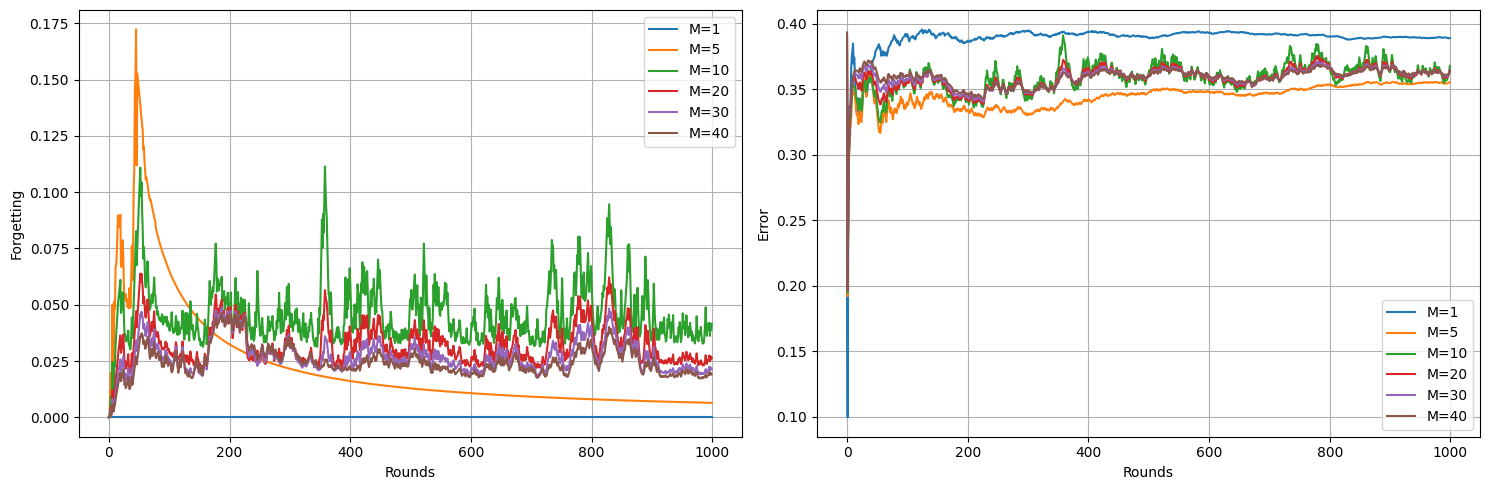

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
d = 10
r = 6
s = 6
N = 7
K = 3
_eta = 0.5
_lambda = 0.3
_alpha = 0.5
sigma_0 = 0.4

M = [1, 5, 10, 20, 30, 40]
beta = 0.1
epsilons = [0.1, 0.15, 0.2, 0.25]
T = 1000
flg = len(M)

def analyze_moe_performance(T, K, M, flg, mt_record, wt_record, wt_record_kl, Ft_record, Gt_record, drift_record, drift_record_kl):
    """
    Analyze MoE performance metrics and generate summary tables
    """
    task_metrics = {
        'Forgetting': np.zeros((flg, K)),
        'Error': np.zeros((flg, K)),
        'Drift': np.zeros((flg, K)),
        'KL-Drift': np.zeros((flg, K))
    }

    for flag in range(flg):
        for task in range(K):
            task_rounds = [t for t in range(T) if mt_record[t] == task]

            if task_rounds:
                task_metrics['Forgetting'][flag, task] = np.mean(Ft_record[flag, task_rounds])
                task_metrics['Error'][flag, task] = np.mean(Gt_record[flag, task_rounds])
                task_metrics['Drift'][flag, task] = np.mean(drift_record[flag, task_rounds])
                task_metrics['KL-Drift'][flag, task] = np.mean(drift_record_kl[flag, task_rounds])

    print("\nMoE Performance Analysis")
    print("=" * 80)

    for metric_name, values in task_metrics.items():
        print(f"\n{metric_name} Analysis:")
        print("-" * 80)
        print(f"{'M':<10}", end="")
        for task in range(K):
            print(f"Task {task+1:>8}", end="")
        print("   Mean   Std")
        print("-" * 80)

        for flag in range(flg):
            print(f"{M[flag]:<10}", end="")
            for task in range(K):
                print(f"{values[flag, task]:8.3f}", end="")
            # Add mean and std across tasks
            print(f"{np.mean(values[flag]):8.3f}{np.std(values[flag]):8.3f}")

    return task_metrics
def update_w(w_last, X_t, y_t):
    return (y_t - w_last @ X_t) @ np.linalg.pinv(X_t) + w_last

def generate_feature_matrix(w_0, v_0, w_index):
    X_t = np.zeros((d,s))
    y_t = np.zeros(s)
    for i in range(0,s):
        temp_X = np.random.randn(r)
        temp_X = 0.1*temp_X/np.linalg.norm(temp_X)
        X_t[:r,i] = temp_X
    v_position = np.random.randint(0,s)
    for i in range(0,d):
        X_t[i,v_position] = v_0[w_index,i]
    for j in range(r,d):
        X_t[j,:] = X_t[j-r,:]*np.random.randn(1)*(0.00001 if j-r == v_position else 0.001)
    y_t = w_0[w_index] @ X_t
    return X_t, y_t

def calculate_task_overlap(w_0, v_0, overlap_threshold=0.25):
    """
    Calculate and track task overlap fractions as discussed in Remark 1.

    Args:
        w_0: Task parameters
        v_0: Task vectors
        overlap_threshold: Threshold to consider regions as overlapping

    Returns:
        overlap_matrix: NxN matrix where entry (i,j) is the fraction of task i
                       that overlaps with task j
        max_overlap: Maximum overlap fraction (Ω_max in the paper)
    """
    N = len(w_0)
    overlap_matrix = np.zeros((N, N))

    # Calculate pairwise overlaps
    for i in range(N):
        for j in range(i+1, N):
            # Calculate normalized parameter similarity
            param_similarity = np.dot(w_0[i,:r], w_0[j,:r]) / (
                np.linalg.norm(w_0[i,:r]) * np.linalg.norm(w_0[j,:r]))

            # Convert to overlap fraction (using sigmoid to bound between 0 and 1)
            overlap = 1 / (1 + np.exp(-10 * (param_similarity - overlap_threshold)))

            overlap_matrix[i,j] = overlap
            overlap_matrix[j,i] = overlap

    # Maximum overlap any task has with others
    max_overlap = np.max(np.sum(overlap_matrix, axis=1))

    return overlap_matrix, max_overlap

def stable_softmax(h_value, eps=1e-9):
    shifted = h_value - np.max(h_value)
    exps = np.exp(shifted)
    denom = np.sum(exps)
    if denom < eps:
        return np.ones_like(h_value) / len(h_value)
    return exps / denom
def soft_max(h_value, flag):
    """Proper softmax for gating probabilities"""
    h_exp = np.exp(h_value)
    return stable_softmax(h_value)
def update_theta(probs, w_init, w_new, X_t, t, mt, flag):
    """
    Implements the gating gradient update from Section 3.2
    Returns the gradient for theta update
    """
    loc_grad = np.zeros((M[flag], d))
    aux_grad = np.zeros((M[flag], d))

    model_error = w_new - w_init
    error_norm = np.linalg.norm(model_error)
    sum_X = np.sum(X_t, axis=1)

    for i in range(M[flag]):
        if i == mt:
            loc_grad[i] = probs[mt] * (1-probs[mt]) * error_norm * sum_X
            aux_grad[i] = probs[mt] * (1-probs[mt]) * _alpha * M[flag]/(t+1) * sum_X
        else:
            loc_grad[i] = -probs[mt] * probs[i] * error_norm * sum_X
            aux_grad[i] = -probs[mt] * probs[i] * _alpha * M[flag]/(t+1) * sum_X

    return loc_grad + aux_grad

def calculate_drift(wt_record, mt_record, w_record, t):
    drift = 0
    counts = np.zeros(len(wt_record[0]))

    for i in range(t):
        expert_idx = mt_record[i]
        counts[expert_idx] += 1
        if counts[expert_idx] > 1:
            initial_params = wt_record[int(counts[expert_idx])][expert_idx]
            current_params = wt_record[i+1][expert_idx]
            drift += np.linalg.norm(current_params - initial_params)

    active_experts = np.sum(counts > 0)
    return drift / max(active_experts, 1)

def cal_F_and_G(t, mt_record, wt_record, w_record):
    if t == 0:
        return 0, np.linalg.norm([x - y for x, y in zip(wt_record[1][mt_record[0]], w_record[0])])

    Ft = sum(abs(np.linalg.norm([x - y for x, y in zip(wt_record[t+1][mt_record[i]], w_record[i])]) -
                np.linalg.norm([x - y for x, y in zip(wt_record[i+1][mt_record[i]], w_record[i])]))
            for i in range(t-1)) / t

    Gt = sum(abs(np.linalg.norm([x - y for x, y in zip(wt_record[t+1][mt_record[i]], w_record[i])]))
            for i in range(t)) / (t+1)

    return Ft, Gt
def generate_ground_truth(w_0, v_0, margin=0.4):
    """
    Generate tasks with explicit margin separation
    Args:
        w_0, v_0: Arrays to store task parameters
        margin: Minimum separation between tasks (δ in the paper)
    """
    for i in range(0, K):
        temp_w = np.random.randn(r)
        temp_w = sigma_0 * temp_w/np.linalg.norm(temp_w)

        if i > 0:
            while True:
                candidate = np.random.randn(r)
                candidate = sigma_0 * candidate/np.linalg.norm(candidate)

                min_distance = min(np.linalg.norm(candidate - w_0[j,:r])
                                 for j in range(i))
                if min_distance > margin:
                    temp_w = candidate
                    break

        temp_v = temp_w/np.linalg.norm(temp_w) * 6
        w_0[i,:r] = temp_w
        v_0[i,:r] = temp_v

    for i in range(K, N):
        temp_w = w_0[i-K,:r] + sigma_0/200*np.random.randn(r)
        temp_v = temp_w/np.linalg.norm(temp_w) * 6
        w_0[i,:r] = temp_w
        v_0[i,:r] = temp_v

    return w_0, v_0

def main():
    w_0 = np.zeros((N, d))
    v_0 = np.zeros((N, d))
    w_pool, v_pool = generate_ground_truth(w_0, v_0)

    index_record = np.random.randint(0, N, T)
    Ft_record = np.zeros((flg, T))
    Gt_record = np.zeros((flg, T))
    drift_record = np.zeros((flg, T))
    drift_record_kl = np.zeros((flg, T))
    epsilon_convergence = {eps: np.zeros((flg, T)) for eps in epsilons}

    for flag in tqdm(range(flg), desc="Processing MoE variants"):
        mt_record = np.ones(T, dtype=int)
        wt_record = np.zeros((T+1, M[flag], d))
        wt_record_kl = np.zeros((T+1, M[flag], d))
        w_record = np.zeros((T, d))
        theta = np.zeros((T+1, M[flag], d))
        expert_record = [[] for _ in range(M[flag])]

        priors = {
            'experts': [None] * M[flag],
            'gating': [None] * M[flag]
        }
        frozen_gates = set()

        for t in range(T):
            w_index = index_record[t]
            Xt, yt = generate_feature_matrix(w_pool, v_pool, w_index)
            w_record[t] = w_pool[w_index]

            for eps in epsilons:
                probs_eps, _, is_confident_eps = gating_decision(theta[t], Xt, flag, epsilon=eps)
                epsilon_convergence[eps][flag, t] = int(is_confident_eps)

            theta[t+1], wt_record[t+1], mt, is_confident, probs = unified_moe_update(
                Xt, yt, theta[t], wt_record[t],
                priors, beta, flag, frozen_gates
            )

            mt_record[t] = mt

            if is_confident:
                frozen_gates.add(mt)
            elif t > 0:
                expert_record[mt].append(w_index)

            w_prior = wt_record[t][mt]
            wt_record_kl[t+1][mt] = update_w_with_kl(
                wt_record_kl[t][mt],
                Xt, yt,
                w_prior,
                beta
            )

            for i in range(M[flag]):
                if i != mt:
                    wt_record_kl[t+1][i] = wt_record_kl[t][i]

            Ft_record[flag,t], Gt_record[flag,t] = cal_F_and_G(t, mt_record, wt_record, w_record)
            drift_record[flag,t] = calculate_drift(wt_record, mt_record, w_record, t)
            drift_record_kl[flag,t] = calculate_drift(wt_record_kl, mt_record, w_record, t)

    overlap_matrix, max_overlap = calculate_task_overlap(w_pool, v_pool)

    performance_metrics = analyze_moe_performance(
        T=T,
        K=K,
        M=M,
        flg=flg,
        mt_record=mt_record,
        wt_record=wt_record,
        wt_record_kl=wt_record_kl,
        Ft_record=Ft_record,
        Gt_record=Gt_record,
        drift_record=drift_record,
        drift_record_kl=drift_record_kl
    )

    forgetting_metrics = analyze_task_forgetting(
        T=T,
        N=N,
        K=K,
        M=M,
        flg=flg,
        wt_record=wt_record,
        wt_record_kl=wt_record_kl,
        mt_record=mt_record,
        Ft_record=Ft_record,
        Gt_record=Gt_record,
        drift_record=drift_record,
        drift_record_kl=drift_record_kl
    )

    plt.figure(figsize=(15, 5))

    plt.subplot(121)
    for i in range(flg):
        plt.plot(Ft_record[i], label=f'M={M[i]}')
    plt.xlabel("Rounds")
    plt.ylabel("Forgetting")
    plt.legend()
    plt.grid(True)

    plt.subplot(122)
    for i in range(flg):
        plt.plot(Gt_record[i], label=f'M={M[i]}')
    plt.xlabel("Rounds")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(True)

    # plt.subplot(153)
    # for i in range(flg):
    #     plt.plot(drift_record[i], '-', label=f'Base M={M[i]}')
    #     plt.plot(drift_record_kl[i], '--', label=f'KL M={M[i]}')
    # plt.xlabel("Rounds")
    # plt.ylabel("Parameter Drift")
    # plt.legend()
    # plt.grid(True)

    # plt.subplot(1)
    # for eps in epsilons:
    #     avg_confidence = np.mean(epsilon_convergence[eps], axis=0)
    #     window = 10
    #     smoothed = np.convolve(avg_confidence, np.ones(window)/window, mode='valid')
    #     plt.plot(smoothed, label=f'ε={eps}')
    # plt.xlabel("Rounds")
    # plt.ylabel("Fraction of Confident Decisions")
    # plt.title("Gating Confidence Analysis")
    # plt.legend()
    # plt.grid(True)

    # plt.subplot(133)
    # im = plt.imshow(overlap_matrix, cmap='YlOrRd', aspect='auto')
    # plt.colorbar(im, label='Overlap Fraction')
    # plt.title(f'Task Overlap (Ω_max={max_overlap:.2f})')
    # plt.xlabel('Task j')
    # plt.ylabel('Task i')

    plt.tight_layout()
    plt.savefig('moe_results_with_overlap.pdf')
    plt.show()
if __name__ == "__main__":
    main()

In [ ]:
def compare():

    w_0 = np.zeros((N, d))
    v_0 = np.zeros((N, d))
    w_pool, v_pool = generate_ground_truth(w_0, v_0)

    index_record = np.random.randint(0, N, T)
    approaches = [
        {
            "name": "Naive",
            "use_kl": False,
            "freeze_gating": False
        },
        {
            "name": "MultiHead",
            "use_kl": False,
            "freeze_gating": False
        }
    ]


    results = {}

    for approach in approaches:
        approach_name = approach["name"]
        print(f"\n=== Running Approach: {approach_name} ===")
        results[approach_name] = {}

        for flag in range(flg):
            m_value = M[flag]
            print(f"\n   Using M={m_value} experts")

            Ft_record_approach = np.zeros(T)
            Gt_record_approach = np.zeros(T)
            drift_record_approach = np.zeros(T)
            drift_record_kl_approach = np.zeros(T)

            mt_record = np.ones(T, dtype=int)
            wt_record = np.zeros((T+1, m_value, d))
            wt_record_kl = np.zeros((T+1, m_value, d))

            w_record = np.zeros((T, d))
            theta = np.zeros((T+1, m_value, d))

            priors = {
                'experts': [None] * m_value,
                'gating': [None] * m_value
            }
            frozen_gates = set()

            for t in range(T):
                w_index = index_record[t]
                Xt, yt = generate_feature_matrix(w_pool, v_pool, w_index)
                w_record[t] = w_pool[w_index]

                if approach_name == "MultiHead":
                    mt = w_index % K
                    if mt >= m_value:
                        mt = m_value - 1
                    is_confident = False
                    probs = np.zeros(m_value)
                    probs[mt] = 1.0
                else:

                    probs, selected_expert, is_confident = gating_decision(
                        theta[t], Xt, flag, epsilon=0.1
                    )
                    mt = selected_expert

                mt_record[t] = mt

                theta[t+1], wt_record[t+1], chosen_expert, gating_conf, _ = unified_moe_update(
                    Xt, yt, theta[t], wt_record[t],
                    priors, 0.0,
                    flag,
                    None
                )

                wt_record_kl[t+1][mt] = update_w(wt_record_kl[t][mt], Xt, yt)

                for i in range(m_value):
                    if i != mt:
                        wt_record_kl[t+1][i] = wt_record_kl[t][i]

                Ft, Gt = cal_F_and_G(t, mt_record, wt_record, w_record)
                Ft_record_approach[t] = Ft
                Gt_record_approach[t] = Gt
                drift_record_approach[t] = calculate_drift(
                    wt_record, mt_record, w_record, t
                )
                drift_record_kl_approach[t] = calculate_drift(
                    wt_record_kl, mt_record, w_record, t
                )

            final_forgetting = np.mean(Ft_record_approach[-50:])
            final_error = np.mean(Gt_record_approach[-50:])
            final_drift = np.mean(drift_record_approach[-50:])
            final_kl_drift = np.mean(drift_record_kl_approach[-50:])

            results[approach_name][m_value] = {
                "forgetting_curve": Ft_record_approach,
                "error_curve": Gt_record_approach,
                "drift_curve": drift_record_approach,
                "kl_drift_curve": drift_record_kl_approach,
                "final_forgetting": final_forgetting,
                "final_error": final_error,
                "final_drift": final_drift,
                "final_kl_drift": final_kl_drift
            }

    for approach_name in results:
        print(f"\n=== Summary for Approach: {approach_name} ===")
        for m_value in results[approach_name]:
            stats = results[approach_name][m_value]
            prit(
                f" M={m_value}: "
                f" final_forgetting={stats['final_forgetting']:.3f}, "
                f" final_error={stats['final_error']:.3f}, "
                f" final_drift={stats['final_drift']:.3f}, "
                f" final_kl_drift={stats['final_kl_drift']:.3f}"
            )
compare()


=== Running Approach: Naive ===

   Using M=1 experts

   Using M=5 experts

   Using M=10 experts

   Using M=20 experts

   Using M=30 experts

   Using M=40 experts

=== Running Approach: MultiHead ===

   Using M=1 experts

   Using M=5 experts

   Using M=10 experts

   Using M=20 experts

   Using M=30 experts

   Using M=40 experts

=== Summary for Approach: Naive ===
 M=1:  final_forgetting=0.227,  final_error=0.392,  final_drift=0.000,  final_kl_drift=0.000
 M=5:  final_forgetting=0.061,  final_error=0.163,  final_drift=28.687,  final_kl_drift=40.816
 M=10:  final_forgetting=0.066,  final_error=0.372,  final_drift=8.494,  final_kl_drift=38.806
 M=20:  final_forgetting=0.046,  final_error=0.371,  final_drift=4.406,  final_kl_drift=19.952
 M=30:  final_forgetting=0.034,  final_error=0.371,  final_drift=3.522,  final_kl_drift=12.869
 M=40:  final_forgetting=0.027,  final_error=0.371,  final_drift=2.823,  final_kl_drift=9.414

=== Summary for Approach: MultiHead ===
 M=1:  final_